<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Soil-Kriging-Analysis/blob/main/kriging_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Library

In [43]:
!pip install pykrige
!pip install openpyxl

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pykrige.ok import OrdinaryKriging

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

Upload Data

In [45]:
from google.colab import files

uploaded = files.upload()

Saving soil.xlsx to soil (1).xlsx


informasi Data

In [47]:
df = pd.read_excel("soil.xlsx")

df.head()


,x,y,lead,zinc
0,181072,333611,299,1022
1,181025,333558,277,1141
2,181165,333537,199,640
3,181298,333484,116,257
4,181307,333330,117,269


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       155 non-null    int64
 1   y       155 non-null    int64
 2   lead    155 non-null    int64
 3   zinc    155 non-null    int64
dtypes: int64(4)
memory usage: 5.0 KB


In [48]:
df['zinc'].describe()

,zinc
count,155.000000
mean,469.716129
std,367.073788
min,113.000000
25%,198.000000
50%,326.000000
75%,674.500000
max,1839.000000


Persiapan Data Spasial

In [50]:
x = df['x'].astype(float).values
y = df['y'].astype(float).values

zinc = df['zinc'].astype(float).values


print("Jumlah titik :",len(zinc))

Jumlah titik : 155


Peta Lokasi Sampel

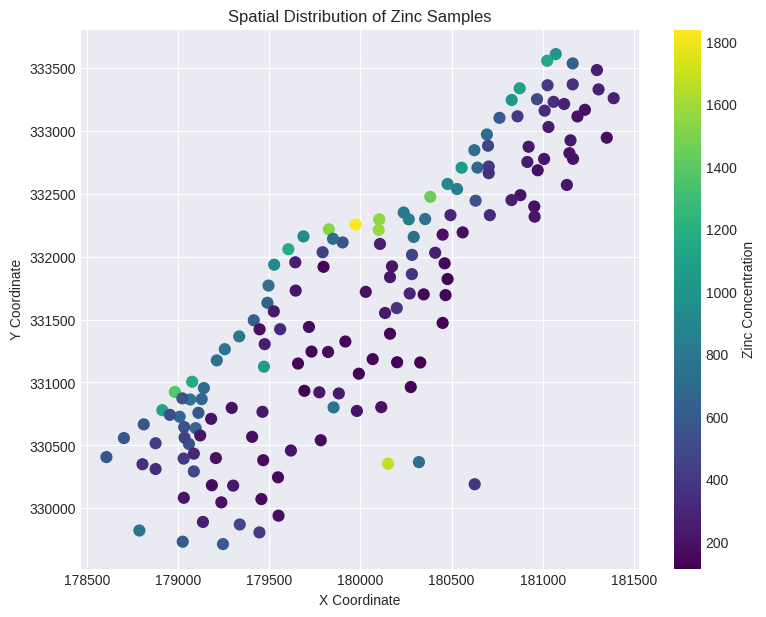

In [51]:
plt.figure(figsize=(9,7))


scatter = plt.scatter(
    x,
    y,
    c=zinc,
    cmap='viridis',
    s=60
)


plt.colorbar(
    scatter,
    label="Zinc Concentration"
)


plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")


plt.title(
    "Spatial Distribution of Zinc Samples"
)


plt.show()

Menghitung Empirical Variogram

In [53]:
from scipy.spatial.distance import pdist, squareform


coords = np.column_stack(
    (x,y)
)


distance = squareform(
    pdist(coords)
)


semivariance = 0.5 * squareform(
    pdist(
        zinc.reshape(-1,1)
    )**2
)


distance_values = distance[np.triu_indices_from(distance,1)]

semi_values = semivariance[np.triu_indices_from(semivariance,1)]

Visualisasi Empirical Variogram

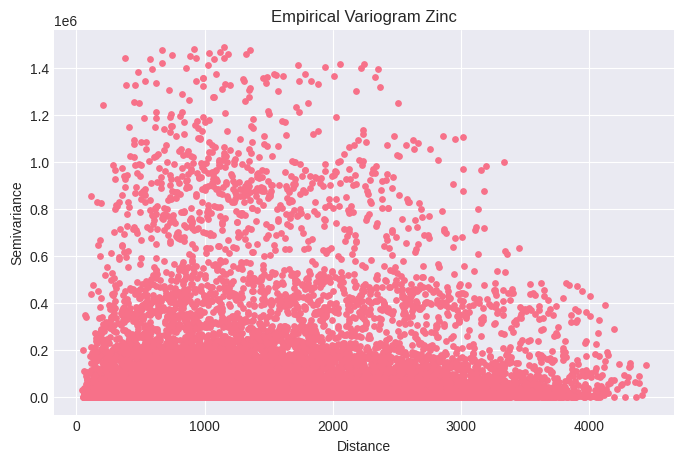

In [54]:
plt.figure(figsize=(8,5))


plt.scatter(
    distance_values,
    semi_values,
    s=15
)


plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Semivariance"
)


plt.title(
    "Empirical Variogram Zinc"
)


plt.show()

Fitting Variogram

In [55]:
from pykrige.ok import OrdinaryKriging


models = [
    'spherical',
    'exponential',
    'gaussian'
]


results={}


for model in models:

    OK_temp = OrdinaryKriging(
        x,
        y,
        zinc,
        variogram_model=model,
        verbose=False
    )

    results[model]=OK_temp.variogram_model_parameters


    print(
        model,
        results[model]
    )

spherical [64672.0196126    785.16946149 66861.18996933]
exponential [114024.07266263    661.07397396  17509.94144694]
gaussian [88775.95771538   600.3201755  42757.25107513]


Membandingkan Model Variogram

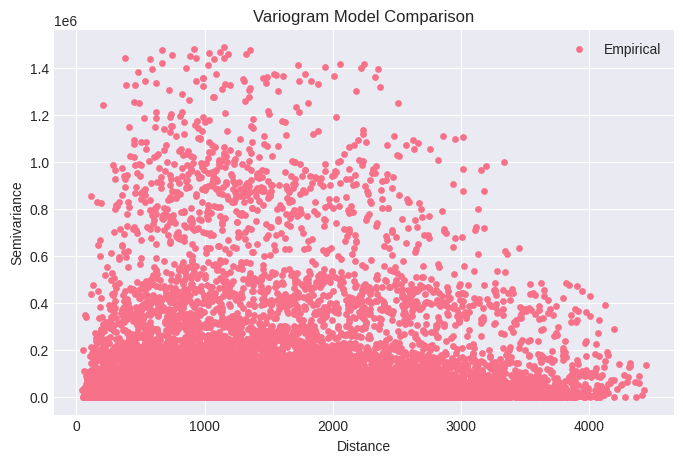

In [57]:
plt.figure(figsize=(8,5))


plt.scatter(
    distance_values,
    semi_values,
    label="Empirical",
    s=15
)


plt.xlabel("Distance")
plt.ylabel("Semivariance")


plt.title(
    "Variogram Model Comparison"
)


plt.legend()

plt.show()

Membuat Grid Prediksi

In [58]:
grid_x = np.linspace(
    x.min(),
    x.max(),
    100
)


grid_y = np.linspace(
    y.min(),
    y.max(),
    100
)

Ordinary Kriging

In [59]:
OK = OrdinaryKriging(

    x,
    y,
    zinc,

    variogram_model='spherical',

    verbose=False,

    enable_plotting=False

)


z_pred, variance = OK.execute(

    'grid',

    grid_x,

    grid_y

)


print(z_pred.shape)

(100, 100)


Peta Prediksi Zinc

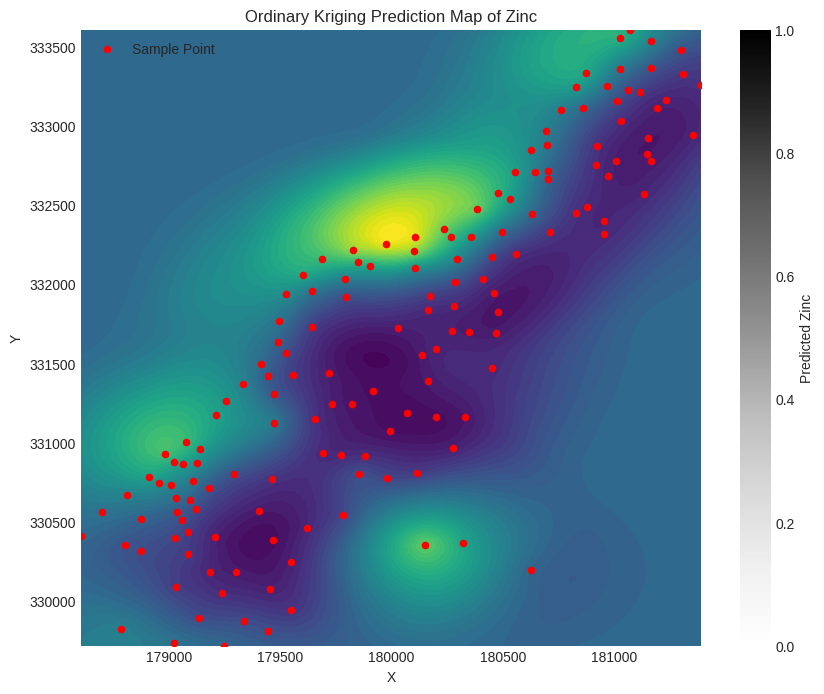

In [60]:
plt.figure(figsize=(10,8))


plt.contourf(

    grid_x,
    grid_y,
    z_pred,

    levels=50,

    cmap='viridis'

)


plt.scatter(
    x,
    y,
    c='red',
    s=20,
    label="Sample Point"
)


plt.colorbar(
    label="Predicted Zinc"
)


plt.title(
"Ordinary Kriging Prediction Map of Zinc"
)


plt.xlabel("X")
plt.ylabel("Y")


plt.legend()


plt.show()

Cross Validation

In [61]:
pred_sample, error = OK.execute(

    'points',

    x,
    y

)


rmse = np.sqrt(
    mean_squared_error(
        zinc,
        pred_sample
    )
)


r2 = r2_score(
    zinc,
    pred_sample
)


print(
"RMSE :",rmse
)


print(
"R2 :",r2
)

RMSE : 2.548801270041932e-12
R2 : 1.0


Grafik Actual vs Predicted

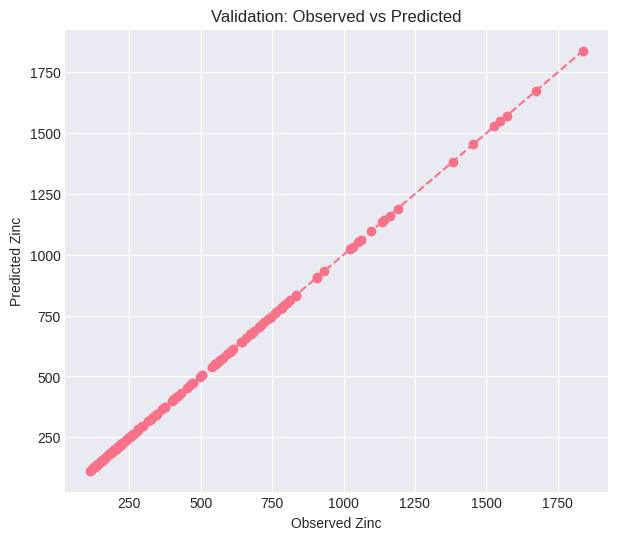

In [62]:
plt.figure(figsize=(7,6))


plt.scatter(
    zinc,
    pred_sample
)


plt.xlabel(
"Observed Zinc"
)


plt.ylabel(
"Predicted Zinc"
)


plt.title(
"Validation: Observed vs Predicted"
)


plt.plot(
[zinc.min(),zinc.max()],
[zinc.min(),zinc.max()],
'--'
)


plt.show()

Analisis Ketidakpastian
Peta Variance Kriging

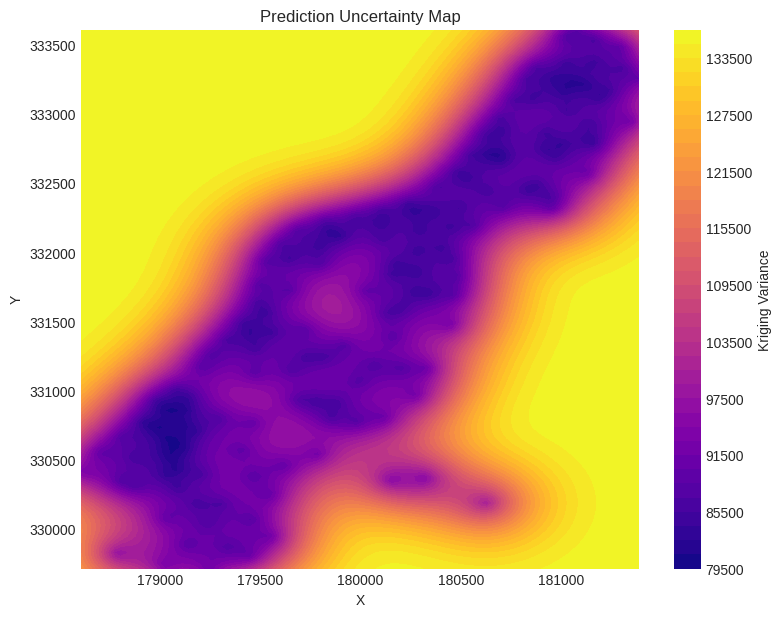

In [63]:
plt.figure(figsize=(9,7))


plt.contourf(

    grid_x,
    grid_y,
    variance,

    levels=50,

    cmap='plasma'

)


plt.colorbar(
label="Kriging Variance"
)


plt.title(
"Prediction Uncertainty Map"
)


plt.xlabel("X")
plt.ylabel("Y")


plt.show()

SUMMARY HASIL

In [64]:
summary = {

"Jumlah Sampel":len(zinc),

"Minimum Zinc":np.min(zinc),

"Maksimum Zinc":np.max(zinc),

"Mean Zinc":np.mean(zinc),

"Std Zinc":np.std(zinc),

"RMSE":rmse,

"R2":r2

}


pd.DataFrame(
summary,
index=[0]
)

,Jumlah Sampel,Minimum Zinc,Maksimum Zinc,Mean Zinc,Std Zinc,RMSE,R2
0,155,113.0,1839.0,469.716129,365.887763,2.548801e-12,1.0


KESIMPULAN OTOMATIS

In [65]:
print(f"""
KESIMPULAN ANALISIS ZINC

Jumlah titik pengamatan sebanyak {len(zinc)} lokasi.

Kandungan Zinc memiliki nilai rata-rata
{np.mean(zinc):.2f} dengan rentang nilai
{np.min(zinc):.2f} hingga {np.max(zinc):.2f}.

Metode Ordinary Kriging berhasil digunakan
untuk melakukan interpolasi spasial Zinc.

Nilai RMSE model sebesar {rmse:.3f}
dengan nilai R2 sebesar {r2:.3f}.

Peta ketidakpastian menunjukkan daerah
dengan variasi prediksi tinggi yang perlu
mendapatkan tambahan sampel.
""")


KESIMPULAN ANALISIS ZINC

Jumlah titik pengamatan sebanyak 155 lokasi.

Kandungan Zinc memiliki nilai rata-rata 
469.72 dengan rentang nilai 
113.00 hingga 1839.00.

Metode Ordinary Kriging berhasil digunakan
untuk melakukan interpolasi spasial Zinc.

Nilai RMSE model sebesar 0.000
dengan nilai R2 sebesar 1.000.

Peta ketidakpastian menunjukkan daerah
dengan variasi prediksi tinggi yang perlu
mendapatkan tambahan sampel.

